<a href="https://colab.research.google.com/github/Elkin535/A---HEURISTICA---Teoria-juego/blob/main/astar_animado_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
pip install matplotlib numpy

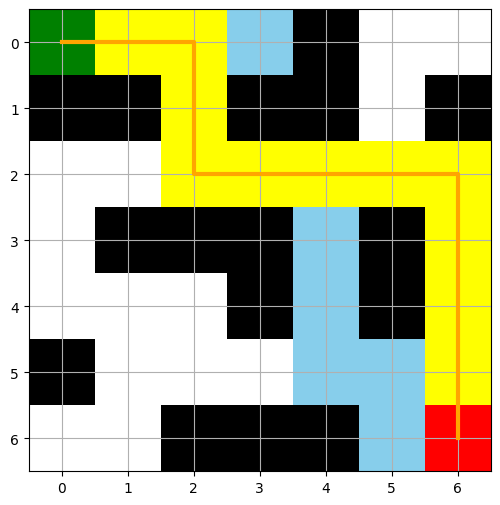

In [41]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython import display as ipythondisplay
import time

# 1. Configuración inicial
grid = np.array([
    [0,0,0,0,1,0,0],
    [1,1,0,1,1,0,1],
    [0,0,0,0,0,0,0],
    [0,1,1,1,0,1,0],
    [0,0,0,1,0,1,0],
    [1,0,0,0,0,0,0],
    [0,0,1,1,1,0,0]
])

start, goal = (0,0), (6,6)
cmap = ListedColormap(["white", "black", "skyblue", "yellow", "green", "red"])
display_grid = np.copy(grid)

# 2. Heurística
def heuristic(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

# 3. PREPARAR EL GRÁFICO (Solo una vez)
fig, ax = plt.subplots(figsize=(6,6))
# Guardamos la imagen en una variable 'im' para actualizarla luego
temp_initial = np.copy(display_grid)
temp_initial[start], temp_initial[goal] = 4, 5
im = ax.imshow(temp_initial, cmap=cmap, vmin=0, vmax=5)
ax.grid(True)
plt.close() # Evita que se muestre una figura vacía extra al inicio

def update_plot():
    temp = np.copy(display_grid)
    temp[start], temp[goal] = 4, 5
    im.set_data(temp) # ¡Truco pro! Solo cambiamos los datos, no el gráfico entero

    ipythondisplay.clear_output(wait=True)
    ipythondisplay.display(fig)
    time.sleep(0.1) # Controla la velocidad aquí (0.1 es 10 cuadros por segundo)

# 4. Algoritmo A*
def astar(grid, start, goal):
    rows, cols = grid.shape
    open_list = [(0, start)]
    came_from, g_cost = {}, {start: 0}

    while open_list:
        current = heapq.heappop(open_list)[1]

        if current != start and current != goal:
            display_grid[current[0]][current[1]] = 2

        update_plot() # Animación

        if current == goal:
            path = []
            while current in came_from:
                path.append(current); current = came_from[current]
            path.append(start); path.reverse()
            return path

        x, y = current
        for nx, ny in [(x+1,y), (x-1,y), (x,y+1), (x,y-1)]:
            if 0 <= nx < rows and 0 <= ny < cols and grid[nx][ny] == 0:
                new_cost = g_cost[current] + 1
                if (nx,ny) not in g_cost or new_cost < g_cost[(nx,ny)]:
                    g_cost[(nx,ny)] = new_cost
                    f = new_cost + heuristic((nx,ny), goal)
                    heapq.heappush(open_list, (f, (nx,ny)))
                    came_from[(nx,ny)] = current
    return None

# 5. Ejecutar y mostrar resultado final
path = astar(grid, start, goal)

if path:
    for p in path:
        if p != start and p != goal:
            display_grid[p[0]][p[1]] = 3

    # Dibujar línea final sobre la última imagen
    x_coords = [p[1] for p in path]
    y_coords = [p[0] for p in path]
    ax.plot(x_coords, y_coords, color="orange", linewidth=3)
    update_plot()